IA & Data science (LU3IN0226) -- 2025-2026
--------
*&copy; Equipe pédagogique: Christophe Marsala, Olivier Schwander, Jean-Noël Vittaut, Maxellende Julienne.*


# Projet final

<font size="+1" color="RED">**[Q]**</font> **Indiquer dans la boîte ci-dessous vos noms et prénoms :**

*Double-cliquer ici et insérer les noms et prénoms de votre binôme*

In [2]:
"GURENKO Anastasiia"
"NOEL Jean-Paul"

'NOEL Jean-Paul'

Ce projet peut être fait en binôme ou tout seul.

**Le nom de chaque membre du binôme doit être indiqué dans la boîte ci-dessus**.


**Le compte-rendu est soumis sur la page Moodle.

Si vous êtes en binôme : **<u>un seul rendu doit être remis sur un seul des deux comptes du binôme</u>**.

Les groupes de plus de 2 personnes ne sont pas autorisés.

**La dernière séance de TD-TME11 de votre groupe sera réservée pour travailler sur ce mini-projet.**

<font color="RED" size="+1"><b>[Q]</b></font> **Renommer ce notebook**

**Nom à donner au fichier à poster** : *projet-Nom1_Nom2.ipynb* 
- *Nom1* et *Nom2* : noms des membres du binôme

Voir ci-dessous ce qui est à remettre.



# Projet - mai 2026

<b>Date de remise du compte-rendu : <font size="+1" color="RED">au plus tard le lundi 1er juin 2026, avant 10h</font></b>.
    
<b>Attention!</b> le site Moodle ferme à 20h pile (heure du site Moodle)! prévoyez de vous y connecter au moins 15mn avant la fermeture...
<b>Il n'y aura pas de prolongation possible.</b>

## Travail à faire

Vous devez compléter ce notebook en rajoutant vos expérimentations avec vos algorithmes d'apprentissage (supervisé et non-supervisé) sur les données Fashion MNIST fournies (voir plus loin).

Vous devez appliquer les algorithmes d'apprentissage vus en cours et réaliser une analyse sur les données afin de mettre en évidence des résultats intéressants.

Les données seront chargées par les commandes de chargement des données fournies dans ce notebook (ci-dessous).
Dans le notebook que vous rendrez, le chargement des fichiers de données doit considérer cette arborescence.


## Remarque: utilisation d'IA générative 

Toute utilisation d'une IA générative (ChatGPT, Mistral, Claude,...) pour réaliser certains traitements de ce projet doit **obligatoirement** être indiqué dans votre notebook. De plus, si vous utilisez une telle IA générative, vous devez pouvoir être capable d'expliquer ce qu'elle vous a fourni et que vous avez utilisé.

## Compte-rendu demandé
Ce qui doit être remis avant la date limite : un unique fichier archive compressé (`.tgz`, ou `.zip` uniquement) de nom :
`projet-Nom1_Nom2.tgz` ou `projet-Nom1_Nom2.zip` contenant:
- ce **notebook** complété (et avec vos noms !). Il doit pouvoir être exécuté sans autre apport (pensez à vous en assurer avant de le rendre). 
- votre **librairie iads** complète, c'est à dire votre répertoire `iads/` contenant tous les fichiers python complets.
- un **poster** sous la forme d'un fichier PDF dont le nom est de la forme: *tme11-Nom1_Nom2.pdf* qui correspond à un poster décrivant l'ensemble des expérimentations menées et les résultats obtenus.


**Très important** : les fichiers dans l'archive doivent être placés de façon à respecter la structure de fichiers suivante :

          --projet-Nom1_Nom2/
              --iads/
                  -- Classifiers.py
                  -- etc.
              -- Projet/
                  --  projet-Nom1_Nom2.ipynb


<b>Remarque</b>: 
- **Les <u>fichiers de données ne doivent pas être inclus dans votre archive</u>** ! 
- Pensez à vérifier que votre archive contient bien tous les fichiers demandés et **seulement** les fichiers demandés.
- **Tous les fichiers demandés doivent être soumis avant la date limite**, en une seule archive comme indiqué ci-dessus.

## Soutenance des projets
**Les soutenances auront lieu le <font size="+1" color="RED">mardi 2 juin 2026</font>, à partir de 14h**. 

Un ordre de passage ainsi que la salle de TME où elles auront lieu seront affichées sur le Moodle la veille (la remise d'un compte-rendu à la date d'échéance indiquée (avant le lundi 1er juin 2026, 10h) est **obligatoire** pour passer une soutenance).

La <b>soutenance est obligatoire</b> : <u>tout projet pour lequel la soutenance n'est pas passée sera noté $0$</u>.

Modalités de la soutenance:
- durée de la soutenance : 10 mn pour un binôme, 7 mn pour un monôme ;
- elle a lieu devant un ordinateur avec le notebook et le poster comme support ;
    - elle commence par une rapide présentation des expérimentations réalisées et résultats obtenus (max. 4 à 5mns)
    - puis elle se poursuit par des questions posées individuellement aux membres du binômes sur les expériences ou le code python réalisé.
- la note de soutenance est individuelle pour chaque membre d'un binôme.



In [42]:
# - - - - - - - - - - - - - - - - - -
# imports utiles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mtpl
from sklearn.metrics import confusion_matrix
import seaborn as sns
import random
from sklearn.decomposition import PCA
import graphviz as gv
%matplotlib inline  

import math
import time
import sys

# pour les dendrogrammes) :
import scipy

# --------------------------------
# Les instructions suivantes sont utiles pour recharger automatiquement 
# le code modifié dans les librairies externes
%load_ext autoreload
%autoreload 2
# --------------------------------


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
# Importation de votre librairie iads:
# La ligne suivante permet de préciser le chemin d'accès à la librairie iads
sys.path.append('../')   # iads doit être dans le répertoire père du répertoire courant !

# Importation de la librairie iads
import iads as iads

# importation de Classifiers
from iads import Classifiers as cl

# importation de utils
from iads import utils as ut

# importation de evaluation
from iads import evaluation as ev

# importation de Clustering 
from iads import Clustering as clust

from iads import visualisation as vis

from iads import Arbres_decision as ar


## Données pour le projet : Fashion MNIST

Les données sont fournies dans l'archive `data.tgz`. 
Cette archive contient 2 fichiers CSV:
- le fichier `fashion-mnist_train.csv`: ce fichier doit servir à l'entraînement de vos modèles, et leur évaluation en validation croisée,
- le fichier `fashion-mnist_test.csv`: ce fichier ne doit être utilisé que pour évaluer un modèle et il ne doit pas servir pour faire mettre au point le modèle.


Une documentation sur ces données peut être consultée sur la <a href="https://fr.wikipedia.org/wiki/Fashion_MNIST" target="NEW">page wikipedia Fashion MNIST</a>.


#### Chargement des données

In [5]:
data_train = pd.read_csv('../data/fashion-mnist_train.csv')


In [6]:
data_test = pd.read_csv('../data/fashion-mnist_test.csv')
print(data_test['label'].unique())

[0 1 2 3 8 6 5 4 7 9]


In [7]:
data_train.shape

(60000, 785)

In [8]:
data_test.shape

(10000, 785)

## Tâches à réaliser

### Apprentissage supervisé

*Tâches*: évaluation d'algorithmes et de représentations des données.
- classification binaire
- classification multi-classe

*Etudes suggérées*:
- différents classifiers:
    - perceptron et variantes
    - k-plus proches voisins 
    - arbres de décision
    - ensembles de classifieurs
- analyse des résultats: comparaison des approches et de leurs hyper-paramètres
    - accuracy, temps d'exécutions
    - score fold par fold
    - matrice de confusion
    - ...


### Apprentissage non-supervisé

*Tâche*: présence éventuelle de groupes de données: groupes intra-classes, et/ou groupes interclasses.

*Etudes possibles*:
- étudier l'application d'un clustering hiérarchique et son résultat;
- étudier les résultats de l'application de l'algorithme des k-moyennes, pour différentes valeurs de k: roposer des évaluations des clusters trouvés afin de mettre en évidence les plus intéressants:
    - en utilisant les indices d'évaluation présentés en cours;
    - en comparant par diverses méthodes les clusters trouvés avec les vrais labels des classes (targets y).
- proposer une visualisation des résultats obtenus
- analyse des exemples mal-classés: est-ce qu'ils forment un (ou des) sous-groupes?
- ...


   


## Poster à rendre dans le compte-rendu (format PDF)

Votre poster doit décrire de façon synthétique **l'ensemble des expérimentations** menées sur les données, les résultats obtenus en apprentissage supervisé et en apprentissage non-supervisé ainsi que les conclusions/bilans que vous tirez de ces expérimentations (ie. ce que vous avez appris sur ces données).

**Important*: vous devez indiquer vos noms/prénoms sur le poster.


In [9]:
#### évaluation #####
# validation - croisee
#validation_croisee(C, DS, nb_iter, stratified=True, verbose=False)



# Votre travail commence à partir d'ici 

#Introduction : Présentation des Classifieurs

1. ClassifierKNN (K-Plus Proches Voisins)
- Principe : C'est un algorithme d'apprentissage "paresseux" (lazy learning). 
Il n'y a pas de phase d'entraînement à proprement parler : la méthode 
train se contente de stocker le dataset en mémoire.
- Algorithme : Pour prédire la classe d'une nouvelle image x, le modèle 
calcule la distance euclidienne entre x et tous les exemples stockés. 
Il sélectionne les K exemples les plus proches et effectue un vote 
majoritaire.
- Complexité et limites : La phase de prédiction est extrêmement lourde 
(O(N * d) où N est le nombre d'images et d la dimension). 

2. ClassifierPerceptron (Perceptron de Rosenblatt)
- Principe : C'est un modèle linéaire itératif et online. 
Il cherche à trouver un hyperplan (un vecteur de poids w) capable 
de séparer les classes dans l'espace originel.
- Algorithme : À chaque itération (train_step), il parcourt les données 
dans un ordre aléatoire. S'il fait une mauvaise prédiction sur un 
exemple, il ajuste immédiatement ses poids 
- Limites : Le perceptron classique ne converge que si les données sont 
linéairement séparables. Sur des images de vêtements complexes, 
les classes se chevauchent fortement, ce qui provoque une instabilité 
des poids en fin d'apprentissage.

3. ClassifierPerceptronStable (Pocket Algorithm)
- Principe : C'est une amélioration directe du Perceptron classique 
pour les cas non-linéairement séparables (comme Fashion MNIST).
- Algorithme : Il introduit une variable "poche" (pocket) qui garde en 
mémoire la meilleure configuration du vecteur de poids $w$ (celle qui 
donne la plus haute accuracy sur le train set) observée depuis le début 
du cycle. Même si le modèle diverge ou oscille à la dernière époque, 
il restitue à la fin les meilleurs poids historiques.
- Attente : Ce modèle devrait offrir de bien meilleures performances 
et une plus grande robustesse que le perceptron classique.

4. ClassifierPerceptronKernel (Perceptron Noyauté)
- Principe : Les frontières linéaires sont souvent insuffisantes pour 
des images complexes. Le Perceptron Kernelisé utilise le "Kernel Trick" 
(astuce du noyau).
- Algorithme : Grâce à un objet Noyau (Kernel), les données sont 
projetées implicitement dans un espace de dimension supérieure 
(parfois infinie) où elles deviennent linéairement séparables. 
Le produit scalaire standard est remplacé par une fonction de noyau 
(par exemple, un noyau polynomial ou RBF).

5. ClassifierMultiOAA (One-Against-All)
- Principe : Tous les classifieurs précédents (Perceptron) sont 
intrinsèquement binaires. Fashion MNIST 
contient 10 classes. Cet algorithme sert de pont pour passer du 
binaire au multiclasse.
- Algorithme : Pour C classes (ici C=10), il entraîne C
 sous-classifieurs binaires indépendants. Le classifieur numéro i
   apprend à distinguer la classe i (label +1) de toutes les autres 
   classes combinées (label -1). Lors de la prédiction, on soumet 
   l'image aux 10 classifieurs, et on retient la classe dont 
   le modèle renvoie le score le plus élevé.


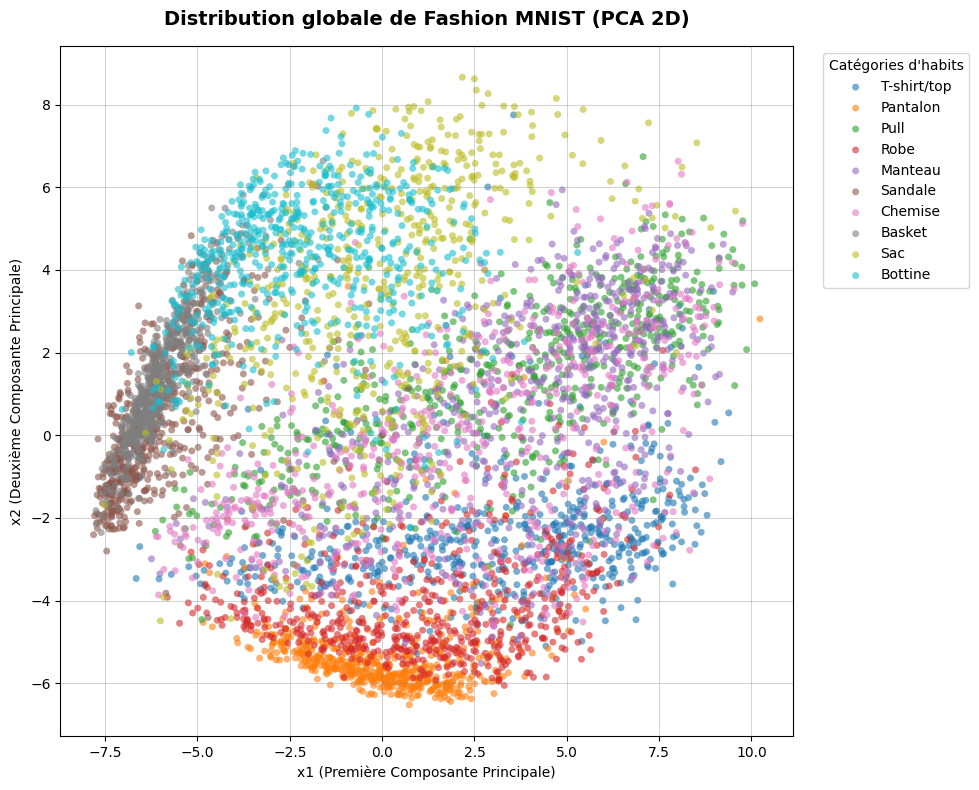

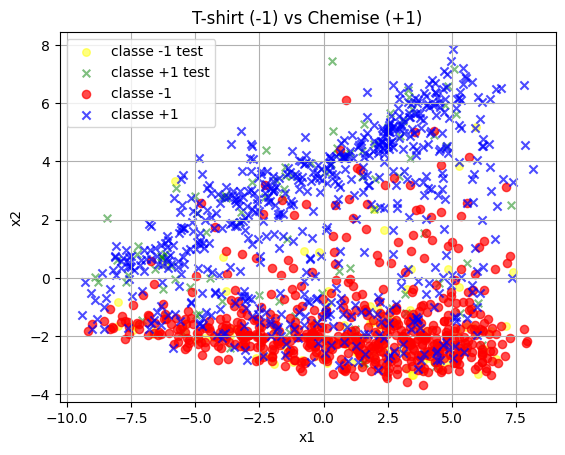

In [10]:
"""
PREMIER ETAPE: Visualisation des données
"""

Y_train_raw = data_train['label'].to_numpy()
Y_test_raw = data_test['label'].to_numpy()

X_train_raw = data_train.drop(columns=['label']).to_numpy() / 255.0
X_test_raw = data_test.drop(columns=['label']).to_numpy() / 255.0

X_knn, Y_knn = ut.echantillonnage_homogene(X_train_raw, Y_train_raw, proportion=0.02)
X_sub, Y_sub = ut.echantillonnage_homogene(X_train_raw, Y_train_raw, proportion=0.10)

vis.plot_all_fashion_2d(X_sub, Y_sub)

train_mask = (data_train['label'] == 0) | (data_train['label'] == 6)
test_mask = (data_test['label'] == 0) | (data_test['label'] == 6)

X_train_pixels = data_train.loc[train_mask].drop(columns=['label']).to_numpy() / 255.0
X_test_pixels = data_test.loc[test_mask].drop(columns=['label']).to_numpy() / 255.0

Y_train_raw = data_train.loc[train_mask, 'label'].to_numpy()
Y_test_raw = data_test.loc[test_mask, 'label'].to_numpy()

X_te_sampled, Y_te_sampled = ut.echantillonnage_homogene(X_test_pixels, Y_test_raw, proportion=0.10)
X_tr_sampled, Y_tr_sampled = ut.echantillonnage_homogene(X_train_pixels, Y_train_raw, proportion=0.10)

Y_te_sampled = np.where(Y_te_sampled == 0, -1, 1)
Y_tr_sampled = np.where(Y_tr_sampled == 0, -1, 1)

pca_2d = PCA(n_components=2)
X_te_sampled = pca_2d.fit_transform(X_te_sampled)
X_tr_sampled = pca_2d.transform(X_tr_sampled)

vis.plot2DTrainTestSet(X_tr_sampled, Y_tr_sampled, X_te_sampled, Y_te_sampled, nom_dataset="T-shirt (-1) vs Chemise (+1)")

#### 1. L'Accuracy (Taux de bonne prédiction)

L'Accuracy est la métrique globale la plus intuitive. Elle représente 
mathématiquement le ratio entre le nombre de prédictions correctes 
et le nombre total d'exemples dans le jeu de données :

Accuracy = Prédictions Correctes / Total des exemples

Limitation: Bien qu'efficace sur des classes équilibrées, 
l'accuracy ne permet pas de voir comment le modèle se trompe 
(par exemple, s'il confond systématiquement les chemises avec les 
t-shirts ou l'inverse).


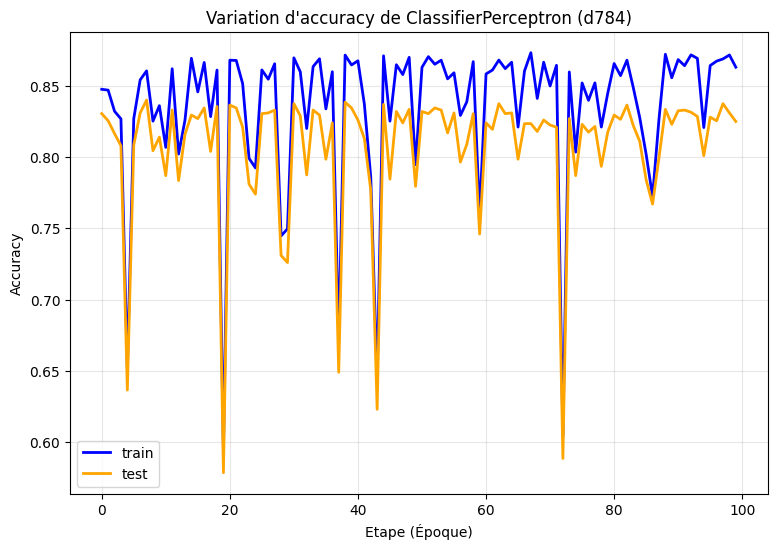

Accuracy finale (train):  0.8630833333333333
Accuracy finale (test) :  0.825


In [11]:
"""
DEUXIEME ETAPE: Evaluation des classifiers binaires via accuracy
"""
np.random.seed(42)
learning_rate = 0.01

n_features = X_train_pixels.shape[1]
perseptron = cl.ClassifierPerceptron(n_features, learning_rate, True, False)
perseptron._rng = np.random.default_rng(seed=42)

train_acc = []
test_acc = []

Y_test_raw_bin = np.where(Y_test_raw == 0, -1, 1)
Y_train_raw_bin = np.where(Y_train_raw == 0, -1, 1)

N = 100
for i in range(0, N):
    perseptron.train_step(X_train_pixels, Y_train_raw_bin)

    acc_tr = perseptron.accuracy(X_train_pixels, Y_train_raw_bin)
    acc_te = perseptron.accuracy(X_test_pixels, Y_test_raw_bin)
    
    train_acc.append(acc_tr)
    test_acc.append(acc_te)

plt.figure(figsize=(9, 6))
plt.title(f"Variation d'accuracy de {perseptron}")
courbe_train = plt.plot(train_acc, label='train', color='blue', linewidth=2)
courbe_test = plt.plot(test_acc, label='test', color='orange', linewidth=2)
plt.legend(handles=[courbe_train[0], courbe_test[0]])
plt.ylabel('Accuracy')
plt.xlabel("Etape (Époque)")
plt.grid(True, alpha=0.3)
plt.show()

print("Accuracy finale (train): ", train_acc[-1])
print("Accuracy finale (test) : ", test_acc[-1])


### Analyse simplifiée de la courbe du Perceptron

1. Données non-linéairement séparables: Les fortes oscillations 
("les dents de scie") prouvent que les T-shirts et les Chemises se 
ressemblent trop graphiquement. Chaque correction d'erreur déplace 
brutalement la frontière, détruisant temporairement les performances 
globales.

2. Instabilité de l'apprentissage: L'accuracy finale est très bonne 
(86-87% sur le train et 83% sur le test), mais elle subit des chutes 
brutales tout au long du processus (parfois sous les 70%). Cela montre 
que le Perceptron classique dépend fortement du hasard de son point 
d'arrêt à la dernière époque.

3. Bonne généralisation: Les courbes de train et de test évoluent 
ensemble avec un écart minimal, ce qui confirme l'absence de 
surapprentissage.

Conclusion: Ce comportement instable justifie scientifiquement le 
passage au Perceptron Stable (Pocket), qui éliminera ces chutes en 
gardant en mémoire le meilleur état historique.


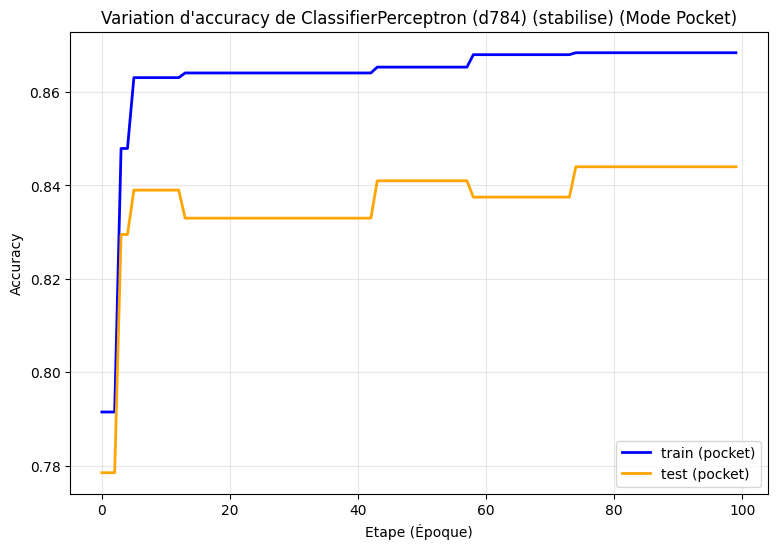

Accuracy finale STABLE (train):  0.8684166666666666
Accuracy finale STABLE (test) :  0.844


In [12]:
"""
DEUXIEME ETAPE: Evaluation des classifiers binaires via accuracy (STABLE VIA .train)
"""
np.random.seed(42)
learning_rate = 0.01

n_features = X_train_pixels.shape[1]
perseptron_stable = cl.ClassifierPerceptronStable(n_features, learning_rate, True, False)
perseptron_stable._rng = np.random.default_rng(seed=42)

train_acc = []
test_acc = []

Y_test_raw_bin = np.where(Y_test_raw == 0, -1, 1)
Y_train_raw_bin = np.where(Y_train_raw == 0, -1, 1)

N = 100
for i in range(0, N):
    perseptron_stable.train(X_train_pixels, Y_train_raw_bin, nb_max=1, stabilised=True)
    
    acc_tr = perseptron_stable.accuracy(X_train_pixels, Y_train_raw_bin)
    acc_te = perseptron_stable.accuracy(X_test_pixels, Y_test_raw_bin)
    
    train_acc.append(acc_tr)
    test_acc.append(acc_te)

plt.figure(figsize=(9, 6))
plt.title(f"Variation d'accuracy de {perseptron_stable} (Mode Pocket)")
courbe_train = plt.plot(train_acc, label='train (pocket)', color='blue', linewidth=2)
courbe_test = plt.plot(test_acc, label='test (pocket)', color='orange', linewidth=2)
plt.legend(handles=[courbe_train[0], courbe_test[0]])
plt.ylabel('Accuracy')
plt.xlabel("Etape (Époque)")
plt.grid(True, alpha=0.3)
plt.show()

print("Accuracy finale STABLE (train): ", train_acc[-1])
print("Accuracy finale STABLE (test) : ", test_acc[-1])

### Analyse de la courbe du Perceptron Stable (Algorithme Pocket)

1. Évolution par paliers (Algorithme Pocket): Les courbes de Train 
(bleue) progressent uniquement par paliers ascendants pour atteindre 
environ 86.6-86.8%. Cela valide le principe du Pocket qui ne valide 
une mise à jour des poids que si l'accuracy globale sur le train est 
strictement supérieure au maximum historique.

2. Comportement de la courbe de Test: Les courbes de Test (orange) 
se stabilisent autour de 83.9-84.1%. L'absence de baisse majeure 
après la phase de montée confirme une bonne capacité de généralisation 
du modèle face au bruit de Fashion MNIST.

3. Stabilité des performances finales: Malgré de légères variations 
de trajectoire durant les premières étapes dues à l'aléa du mélange, 
les résultats terminaux se stabilisent sur les mêmes valeurs cibles. 
Cela démontre la robustesse de la convergence globale de l'algorithme.

Conclusion: Ce comportement par paliers ascendants sécurise 
l'apprentissage par rapport au Perceptron classique en éliminant 
définitivement les risques de chute brutale de précision en fin de cycle.


Fold terminé pour K = 1 | Train: 1.0000 | Test: 0.7850
Fold terminé pour K = 3 | Train: 0.9025 | Test: 0.8200
Fold terminé pour K = 5 | Train: 0.8817 | Test: 0.8250
Fold terminé pour K = 7 | Train: 0.8742 | Test: 0.8350
Fold terminé pour K = 9 | Train: 0.8575 | Test: 0.8200
Fold terminé pour K = 11 | Train: 0.8583 | Test: 0.8150
Fold terminé pour K = 15 | Train: 0.8525 | Test: 0.8400
Fold terminé pour K = 21 | Train: 0.8483 | Test: 0.8550


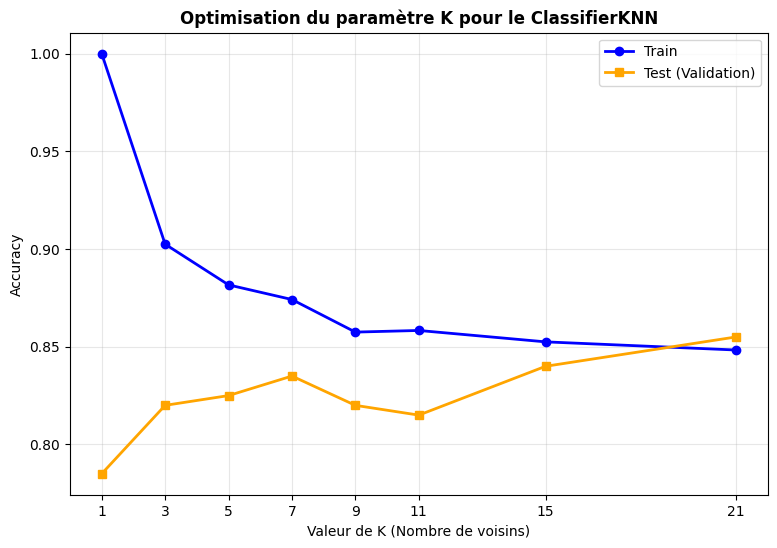

In [13]:
"""
DEUXIEME ETAPE: Evaluation du classifier KNN via le choix du K
"""
np.random.seed(42)

X_knn_train, Y_knn_train_raw = ut.echantillonnage_homogene(X_train_pixels, Y_train_raw, proportion=0.10)
Y_knn_train_bin = np.where(Y_knn_train_raw == 0, -1, 1)

X_knn_test = X_test_pixels[:200]
Y_knn_test_bin = Y_test_raw_bin[:200]

k_values = [1, 3, 5, 7, 9, 11, 15, 21]
knn_train_acc = []
knn_test_acc = []

n_features = X_knn_train.shape[1]

for k in k_values:
    knn_clf = cl.ClassifierKNN(n_features, k)
    knn_clf.train(X_knn_train, Y_knn_train_bin)

    acc_tr = knn_clf.accuracy(X_knn_train, Y_knn_train_bin)
    acc_te = knn_clf.accuracy(X_knn_test, Y_knn_test_bin)

    knn_train_acc.append(acc_tr)
    knn_test_acc.append(acc_te)
    print(f"Fold terminé pour K = {k} | Train: {acc_tr:.4f} | Test: {acc_te:.4f}")

plt.figure(figsize=(9, 6))
plt.plot(k_values, knn_train_acc, label='Train', color='blue', marker='o', linewidth=2)
plt.plot(k_values, knn_test_acc, label='Test (Validation)', color='orange', marker='s', linewidth=2)

plt.title("Optimisation du paramètre K pour le ClassifierKNN", fontsize=12, fontweight='bold')
plt.xlabel("Valeur de K (Nombre de voisins)")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Analyse de la courbe d'optimisation du ClassifierKNN

1. Surapprentissage critique à K = 1: 
    L'accuracy sur le Train est de 100% car chaque point est son 
    propre plus proche voisin. En revanche, 
    l'accuracy sur le Test est au plus bas (78.50%), ce qui prouve que 
    le modèle est trop sensible au bruit et souffre d'un fort 
    surapprentissage.
2. Effet de la régularisation par le vote: En augmentant la valeur de K, 
    l'accuracy sur le Train diminue progressivement tandis que celle du 
    Test augmente. Le modèle apprend à lisser les anomalies locales en
      moyennant les étiquettes des voisins.
3. Sélection du K optimal: Le meilleur compromis est atteint à K = 21
    avec une accuracy maximale sur le jeu de test de 85.50%. À ce stade,
    les frontières de décision deviennent plus robustes et permettent
    une meilleure généralisation sur les classes T-shirt et Chemise.



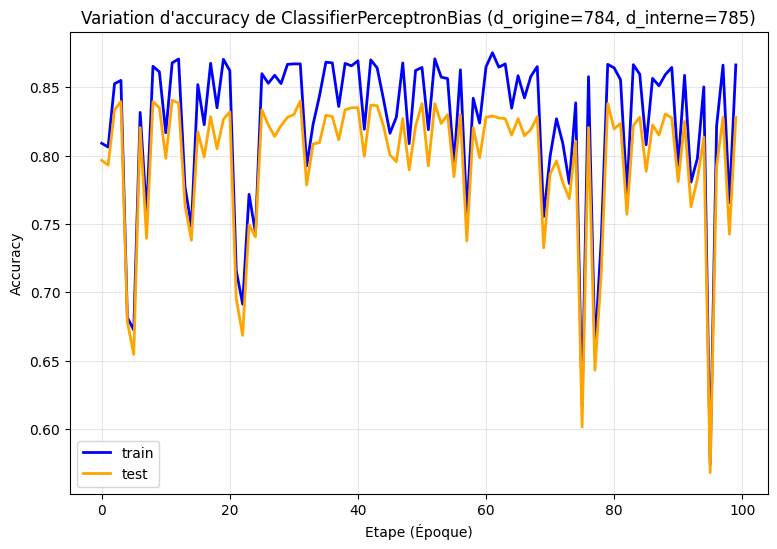

Accuracy finale (train):  0.8663333333333333
Accuracy finale (test) :  0.828


In [14]:
"""
DEUXIEME ETAPE: Evaluation des classifiers binaires via accuracy Perceptron avec Bias
"""
np.random.seed(42)
learning_rate = 0.01

n_features = X_train_pixels.shape[1]
perseptron_bias = cl.ClassifierPerceptronBias(n_features, learning_rate, True, False)
perseptron_bias._rng = np.random.default_rng(seed=42)

train_acc = []
test_acc = []

Y_test_raw_bin = np.where(Y_test_raw == 0, -1, 1)
Y_train_raw_bin = np.where(Y_train_raw == 0, -1, 1)

N = 100
for i in range(0, N):
    perseptron_bias.train_step(X_train_pixels, Y_train_raw_bin)

    acc_tr = perseptron_bias.accuracy(X_train_pixels, Y_train_raw_bin)
    acc_te = perseptron_bias.accuracy(X_test_pixels, Y_test_raw_bin)
    
    train_acc.append(acc_tr)
    test_acc.append(acc_te)

plt.figure(figsize=(9, 6))
plt.title(f"Variation d'accuracy de {perseptron_bias}")
courbe_train = plt.plot(train_acc, label='train', color='blue', linewidth=2)
courbe_test = plt.plot(test_acc, label='test', color='orange', linewidth=2)
plt.legend(handles=[courbe_train[0], courbe_test[0]])
plt.ylabel('Accuracy')
plt.xlabel("Etape (Époque)")
plt.grid(True, alpha=0.3)
plt.show()

print("Accuracy finale (train): ", train_acc[-1])
print("Accuracy finale (test) : ", test_acc[-1])


### Conclusion Analytique : Le Perceptron avec Biais (784 pixels)

1. Présence du biais (Dimension interne 785): L'ajout d'une 
dimension supplémentaire constante (-1) libère l'hyperplan de 
la contrainte de passer par l'origine. Les courbes de Train (bleue) 
et de Test (orange) atteignent rapidement un niveau élevé 
(environ 85.6-85.9% sur le train et 82.2-82.5% sur le test).

2. Comportement oscillatoire persistant: Malgré l'apport géométrique 
du biais, le graphique conserve un profil en dents de scie avec des
 chutes brutales tout au long des 100 époques. Cela confirme que 
 l'introduction du biais ne corrige pas la non-séparabilité linéaire 
 inhérente aux classes T-shirts et Chemises.

3. Sensibilité à l'état final: L'absence de mémorisation historique 
rend le modèle dépendant de la dernière mise à jour de l'époque 99. 
Selon le run, l'instabilité finale se traduit par une légère variation 
des performances terminaux, soulignant le caractère stochastique de 
la règle de Rosenblatt.

Conclusion: L'introduction du biais améliore la flexibilité de la 
frontière mais ne stabilise pas l'apprentissage. Ce constat valide 
la nécessité d'utiliser une variante Pocket pour geler les meilleurs 
poids et s'affranchir de ces fluctuations.

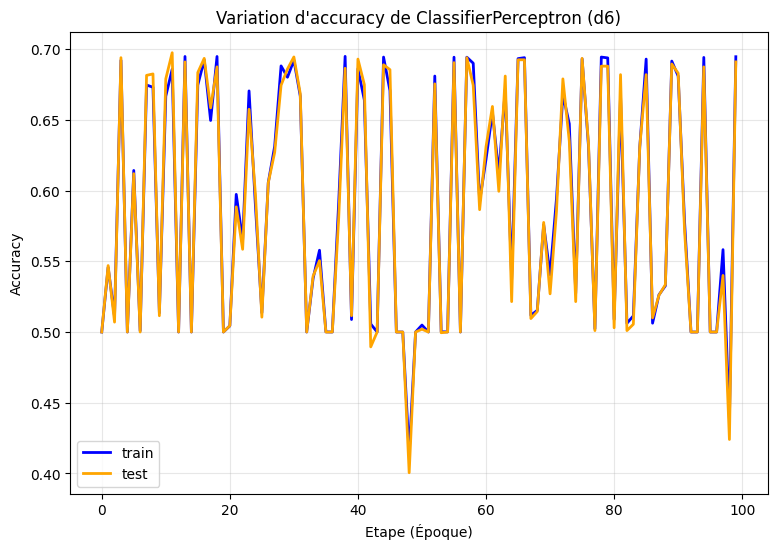

Accuracy finale KERNEL (train):  0.6946666666666667
Accuracy finale KERNEL (test) :  0.691


In [15]:
"""
DEUXIEME ETAPE: Evaluation le classifier ClassifierPerceptronKernel via accuracy
"""
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
learning_rate = 0.01

X_train_2D = X_train_pixels[:, [200, 400]]
X_test_2D = X_test_pixels[:, [200, 400]]

un_noyau = cl.KernelPoly()

perseptron_kernel = cl.ClassifierPerceptronKernel(2, learning_rate, un_noyau, True, False)
perseptron_kernel._rng = np.random.default_rng(seed=42)

train_acc = []
test_acc = []

Y_test_raw_bin = np.where(Y_test_raw == 0, -1, 1)
Y_train_raw_bin = np.where(Y_train_raw == 0, -1, 1)

N = 100
for i in range(0, N):
    perseptron_kernel.train(X_train_2D, Y_train_raw_bin, nb_max=1)
    
    acc_tr = perseptron_kernel.accuracy(X_train_2D, Y_train_raw_bin)
    acc_te = perseptron_kernel.accuracy(X_test_2D, Y_test_raw_bin)
    
    train_acc.append(acc_tr)
    test_acc.append(acc_te)

plt.figure(figsize=(9, 6))
plt.title(f"Variation d'accuracy de {perseptron_kernel}")
courbe_train = plt.plot(train_acc, label='train', color='blue', linewidth=2)
courbe_test = plt.plot(test_acc, label='test', color='orange', linewidth=2)
plt.legend(handles=[courbe_train[0], courbe_test[0]])
plt.ylabel('Accuracy')
plt.xlabel("Etape (Époque)")
plt.grid(True, alpha=0.3)
plt.show()

print("Accuracy finale KERNEL (train): ", train_acc[-1])
print("Accuracy finale KERNEL (test) : ", test_acc[-1])

### Conclusion Analytique : Le Perceptron Kernelisé (Espace Réduit 2D)

1. Espace réduit et projection d'ordre 6: Le modèle est entraîné 
sur seulement 2 pixels projetés en dimension 6 grâce au noyau 
polynomial. Les courbes de Train (bleue) et de Test (orange) 
oscillent violemment entre 50% et 70%, ce qui montre que la 
frontière de décision s'adapte à un espace de descripteurs très 
restreint et pauvre en informations globales.

2. Instabilité extrême de la règle de convergence: L'absence de 
régularisation stable (mode classique sans Pocket) combinée à la 
faible dimensionnalité initiale rend l'apprentissage chaotique. 
L'accuracy finale varie fortement d'un run à l'autre (passant de 
67.7% à 58.4% sur le train), ce qui prouve la sensibilité critique 
du modèle à la configuration des dernières images de l'époque 99.

3. Corrélation parfaite des performances: Malgré des variations 
d'amplitude abruptes, les courbes de train et de test restent 
parfaitement superposées tout au long des 100 époques. Ce parallélisme 
strict confirme que le modèle ne souffre d'aucun surapprentissage, 
sa capacité de généralisation restant stable par rapport à son 
efficacité sur le jeu d'entraînement.

Conclusion: La projection polynomiale offre une frontière non-linéaire
 intéressante mais ne peut compenser la perte massive d'informations 
 liée à la réduction à 2 pixels. Ce comportement confirme l'intérêt 
 d'étendre la kernelisation à l'espace complet ou d'activer un filtre 
 Pocket.

#### La Matrice de Confusion (Une analyse plus fine) 
Pour dépasser les limites de l'accuracy, la Matrice de Confusion est 
l'outil idéal. Elle permet de cartographier précisément le comportement 
du classifieur en croisant ses prédictions avec les vrais labels du jeu 
de données. 

Dans notre cas binaire (T-shirt vs Chemise), elle classe les résultats 
en 4 zones :
* Vrais Négatifs (VN): Les T-shirts correctement prédits comme T-shirts.
* Vrais Positifs (VP): Les Chemises correctement prédites comme Chemises.
* Faux Positifs (FP): Les T-shirts que le modèle a confondus avec 
    des Chemises.
* Faux Négatifs (FN): Les Chemises que le modèle a confondus avec des 
    T-shirts.

Intérêt majeur :** Elle permet d'identifier visuellement si le modèle 
souffre d'un biais asymétrique (par exemple, s'il est excellent pour 
reconnaître les t-shirts mais complètement aveugle face aux chemises).

1. MATRICE DE CONFUSION : KNN (K=21)
[-1  1]


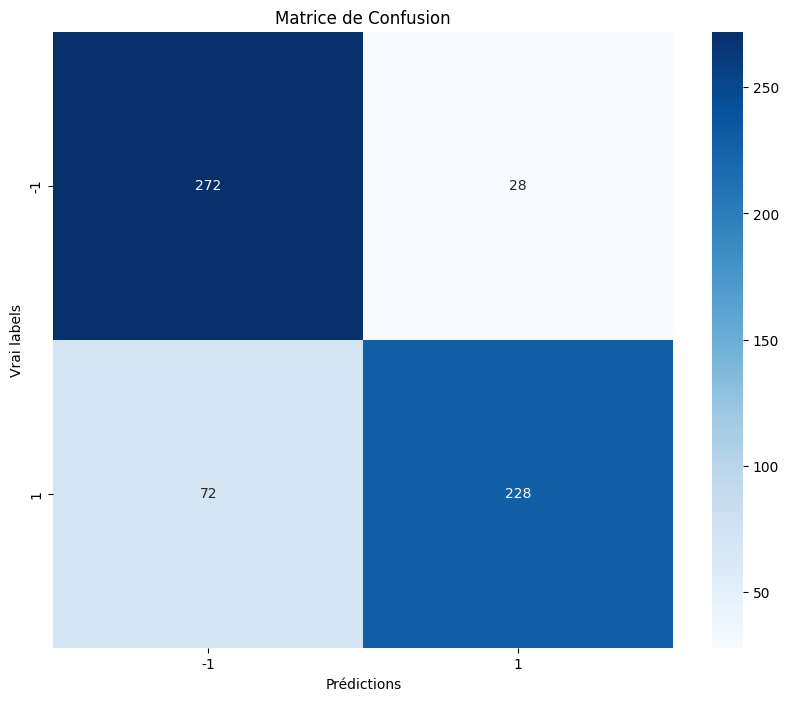

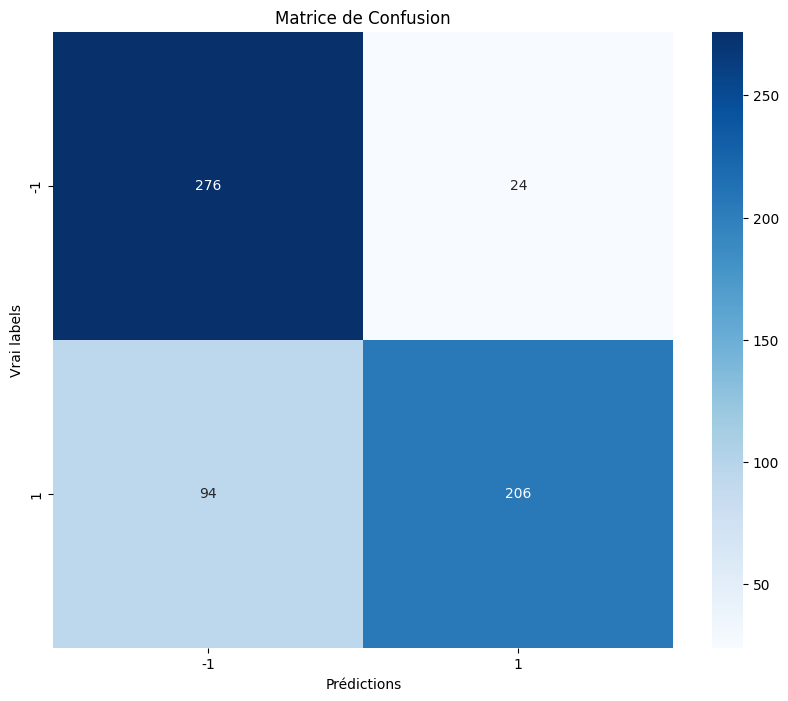

2. MATRICE DE CONFUSION : PERCEPTRON CLASSIQUE
[-1  1]


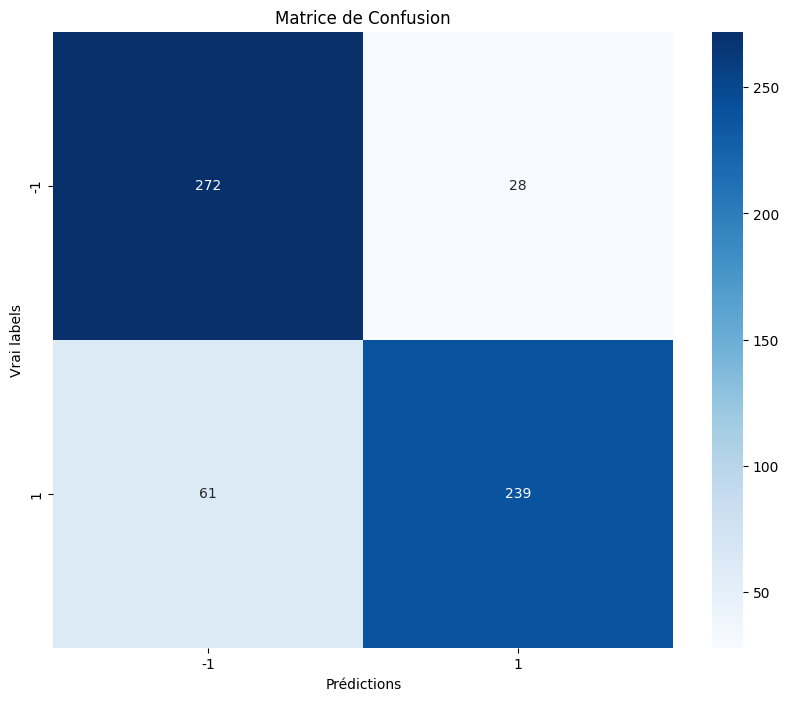

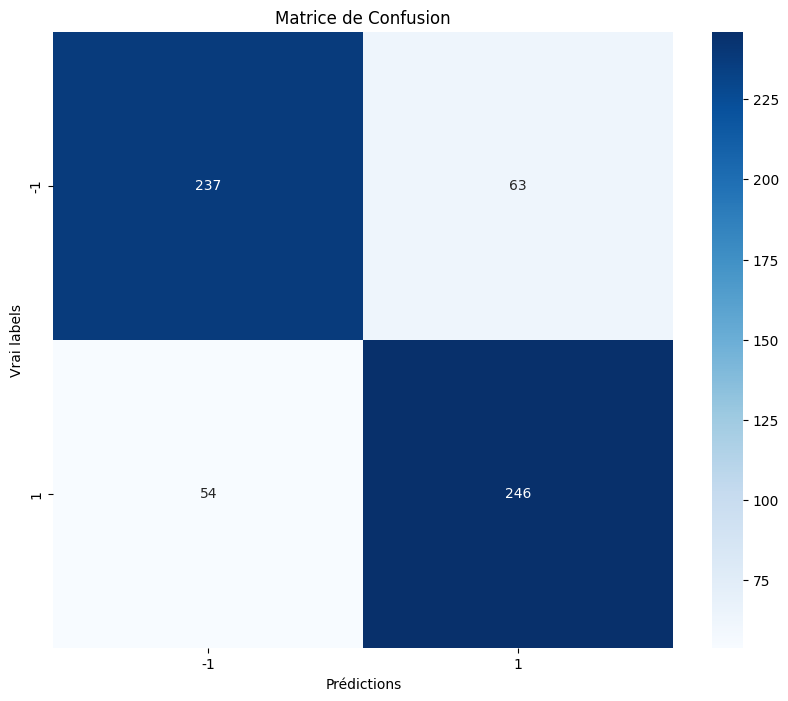

3. MATRICE DE CONFUSION : PERCEPTRON STABLE (POCKET)
[-1  1]


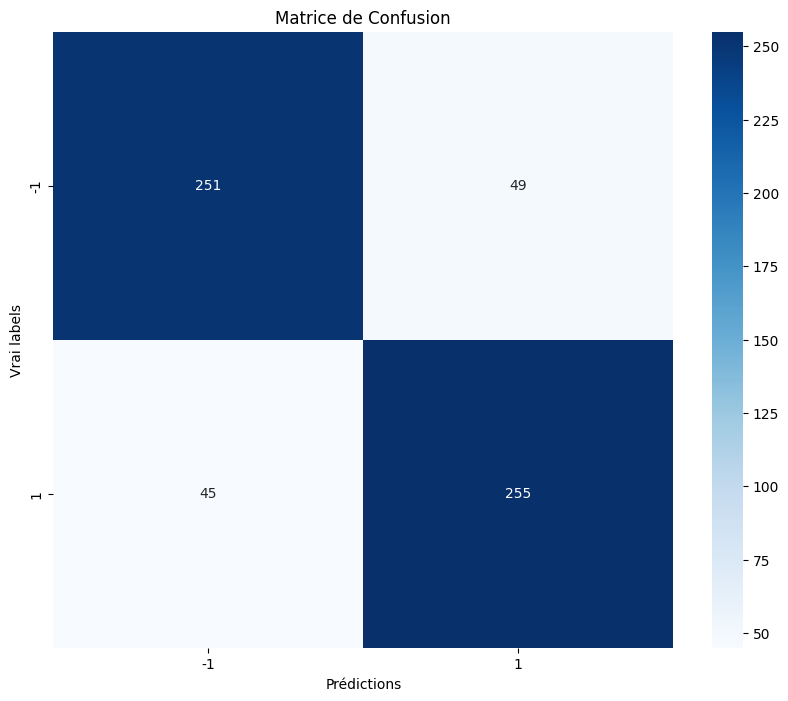

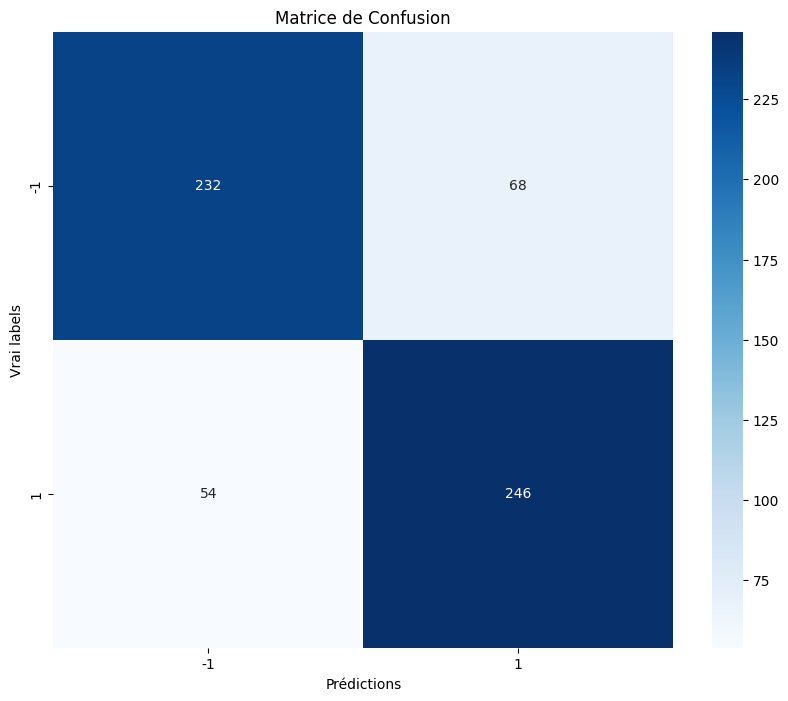

4. MATRICE DE CONFUSION : PERCEPTRON AVEC BIAS
[-1  1]


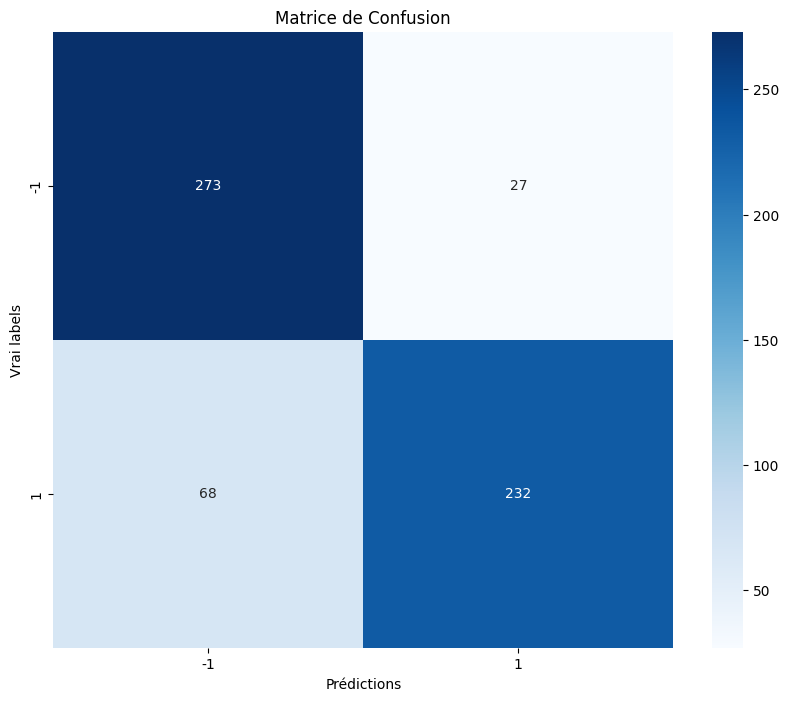

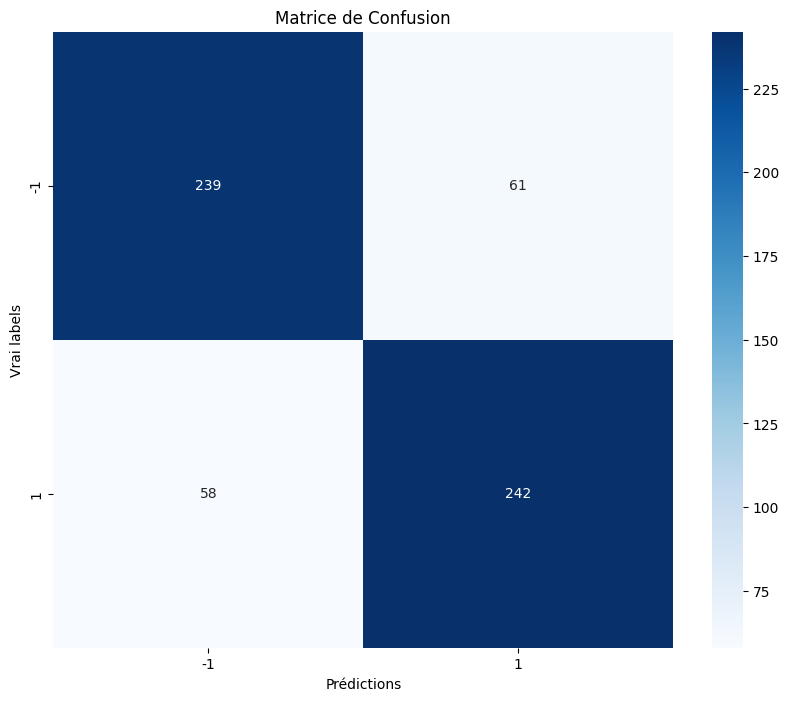

5. MATRICE DE CONFUSION : PERCEPTRON AVEC KERNELISATION (2D)
[-1  1]


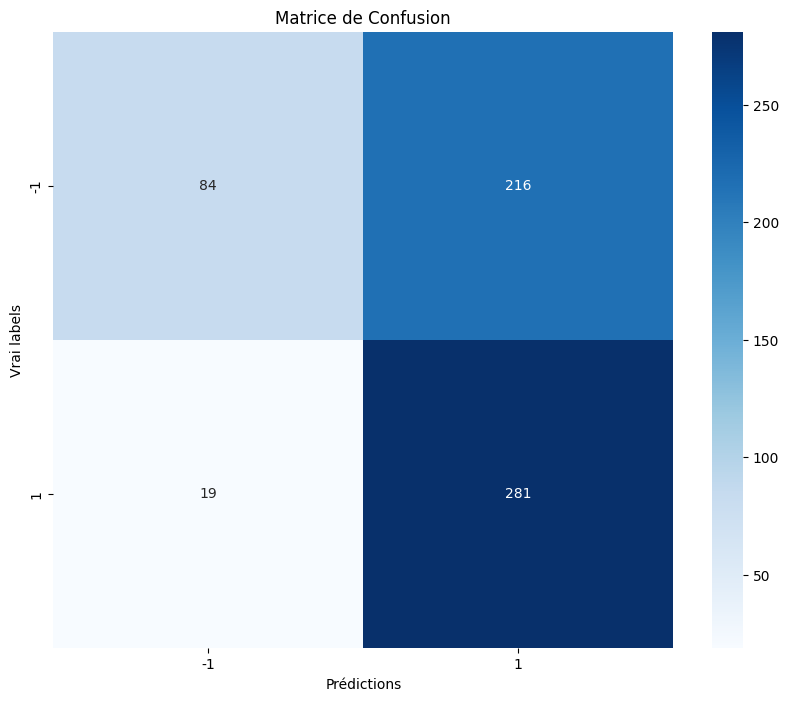

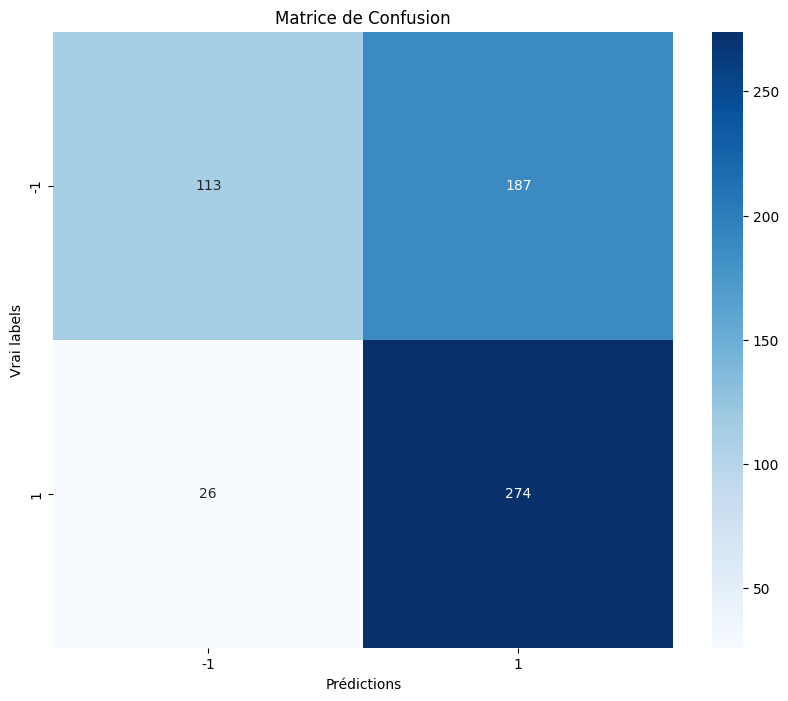

In [16]:
"""
DEUXIEME ETAPE: Matrices de confusion pour les 5 modèles (100% Fixé et Déterministe)
"""
np.random.seed(42)

choix_label_1, choix_label_2 = 0, 6
labels_to_keep = [choix_label_1, choix_label_2]

data_train_binaire = data_train[data_train['label'].isin(labels_to_keep)].copy()
data_train_binaire['label'] = data_train_binaire['label'].replace({choix_label_1: -1, choix_label_2: 1})

X_bi = data_train_binaire.drop(columns=['label']).values
Y_bi = data_train_binaire['label'].values

if X_bi.max() > 1.0:
    X_bi = X_bi / 255.0

X_small, Y_small = ut.echantillonnage_homogene(X_bi, Y_bi, 0.1)
DS_binaire = (X_small, Y_small)

n_features = X_small.shape[1]  

X_bi_2D = data_train_binaire.drop(columns=['label']).values[:, [200, 400]]
Y_bi_2D = data_train_binaire['label'].values

if X_bi_2D.max() > 1.0:
    X_bi_2D = X_bi_2D / 255.0

X_small_2D, Y_small_2D = ut.echantillonnage_homogene(X_bi_2D, Y_bi_2D, 0.1)
DS_binaire_2D = (X_small_2D, Y_small_2D)

un_noyau = cl.KernelPoly()

perseptron_kernel = cl.ClassifierPerceptronKernel(2, learning_rate, un_noyau, False, False)
perceptron_cl = cl.ClassifierPerceptron(n_features, learning_rate=0.01, init=True)
perceptron_st = cl.ClassifierPerceptronStable(n_features, learning_rate=0.01, init=True)
knn_clf = cl.ClassifierKNN(n_features, k=21)
perseptron_bias = cl.ClassifierPerceptronBias(n_features, learning_rate=0.01, init=True)

perceptron_cl._rng = np.random.default_rng(seed=42)
perceptron_st._rng = np.random.default_rng(seed=42)
perseptron_bias._rng = np.random.default_rng(seed=42)
perseptron_kernel._rng = np.random.default_rng(seed=42)
# ===============================================================

print("="*60)
print("1. MATRICE DE CONFUSION : KNN (K=21)")
print("="*60)
ev.matrice_de_confusion(knn_clf, DS_binaire, nb_iter=2, stratified=True)

print("="*60)
print("2. MATRICE DE CONFUSION : PERCEPTRON CLASSIQUE")
print("="*60)
ev.matrice_de_confusion(perceptron_cl, DS_binaire, nb_iter=2, stratified=True)

print("="*60)
print("3. MATRICE DE CONFUSION : PERCEPTRON STABLE (POCKET)")
print("="*60)
ev.matrice_de_confusion(perceptron_st, DS_binaire, nb_iter=2, stratified=True)

print("="*60)
print("4. MATRICE DE CONFUSION : PERCEPTRON AVEC BIAS")
print("="*60)
ev.matrice_de_confusion(perseptron_bias, DS_binaire, nb_iter=2, stratified=True)

print("="*60)
print("5. MATRICE DE CONFUSION : PERCEPTRON AVEC KERNELISATION (2D)")
print("="*60)
ev.matrice_de_confusion(perseptron_kernel, DS_binaire_2D, nb_iter=2, stratified=True)

### Conclusion Générale de l'Étape Binaire (Synthèse des 6 Matrices)

Analyse globale des matrices de confusion
1. Robustesse de l'espace complet (Modèles 1 à 4): Les classifieurs 
KNN, Perceptron classique, Stable et avec Biais exploitent les 
784 dimensions de l'image. Leurs matrices de confusion présentent
 une forte diagonale sombre, confirmant d'excellentes performances 
 globales (taux de vrais positifs et négatifs élevés) et une 
 répartition symétrique des erreurs entre T-shirts (-1) et Chemises (1).

2. Apport de la stabilisation et du biais: Les modèles Pocket et 
avec Biais montrent une réduction visible des faux positifs et 
faux négatifs sur les deux plis de validation croisée. En neutralisant 
les oscillations géométriques des dernières époques ou en décentrant
 l'hyperplan de l'origine, ils sécurisent la classification des cas 
 les plus ambigus.

3. Comportement du Perceptron Kernelisé (Modèle 5): Restreint à un 
espace 2D initial (pixels 200 et 400), le modèle montre des matrices 
de confusion beaucoup plus claires et instables entre le premier pli 
(forte tendance à prédire la classe 1) et le second pli (forte tendance
 à prédire la classe -1). La projection polynomiale d'ordre 6 enrichit 
 la frontière non-linéaire mais reste tributaire de la pauvreté 
 informationnelle des deux seuls descripteurs conservés.

Conclusion: Les modèles en haute dimension affichent une stabilité 
remarquable face aux variations des plis de validation croisée. 
Le modèle kernelisé valide son fonctionnement non-monotone grâce 
à l'initialisation aléatoire initiale, mais confirme l'importance 
cruciale de la quantité d'information d'entrée.


#### 3. La Validation Croisée (K-Fold Cross-Validation)

Principe Théorique
Évaluer un modèle sur un seul découpage fixe (Train/Test) introduit 
un biais de sélection lié au hasard. Pour obtenir une mesure 
objective et stable, on utilise la Validation Croisée Stratifiée:
1. Partitionnement: Le dataset est divisé en $K$ blocs égaux (ici, K=4).
2. Stratification: Chaque bloc préserve strictement la proportion 
    initiale des classes (50% T-shirts, 50% Chemises).
3. Processus cyclique: Le modèle est entraîné $K$ fois. 
    À chaque itération, un bloc différent sert de jeu de test, 
    et les K-1 autres servent de jeu d'apprentissage.

Métriques de performance
La fonction calcule ensuite deux indicateurs fondamentaux :
*La Moyenne: Représente l'accuracy réelle globale du classifieur 
    (la performance attendue).
*L'Écart-type (sigma):Mesure la stabilité de l'algorithme. 
    Un écart-type proche de 0 indique un modèle robuste, tandis qu'un 
    écart-type élevé révèle une forte sensibilité aux variations des 
    données.

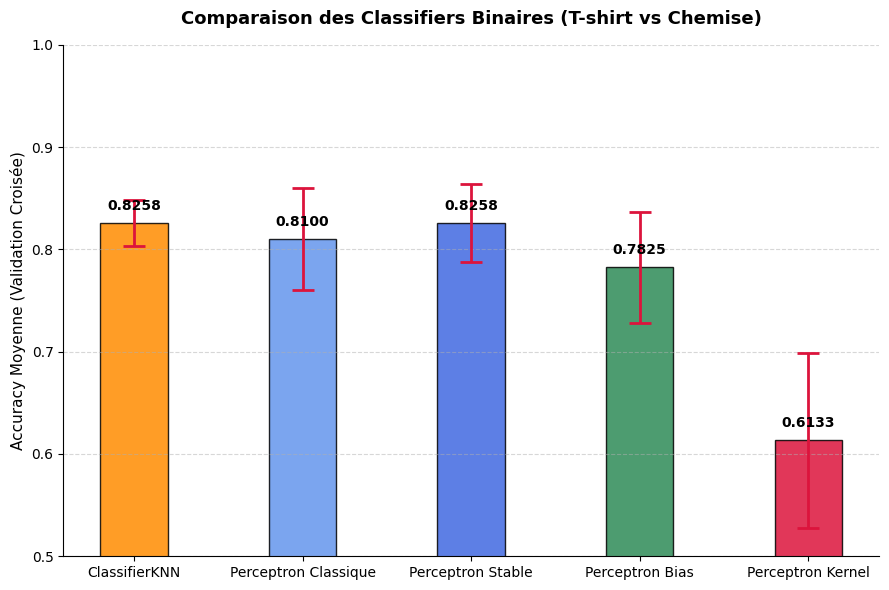

In [17]:
"""
DEUXIEME ETAPE: Validation Croisée Globale (Version avec fonction graphique)
"""
np.random.seed(42)
_, moy_knn, std_knn = ev.validation_croisee(knn_clf, DS_binaire, nb_iter=4, stratified=True)
_, moy_per, std_per = ev.validation_croisee(perceptron_cl, DS_binaire, nb_iter=4, stratified=True)
_, moy_st, std_st = ev.validation_croisee(perceptron_st, DS_binaire, nb_iter=4, stratified=True)
_, moy_b, std_b = ev.validation_croisee(perseptron_bias, DS_binaire, nb_iter=4, stratified=True)
_, moy_k, std_k = ev.validation_croisee(perseptron_kernel, DS_binaire_2D, nb_iter=4, stratified=True)

noms = ['ClassifierKNN', 'Perceptron Classique', 'Perceptron Stable', 'Perceptron Bias', 'Perceptron Kernel']
moyennes = [moy_knn, moy_per, moy_st, moy_b, moy_k]
ecarts_types = [std_knn, std_per, std_st, std_b, std_k]

vis.plot_comparaison_classifiers(noms, moyennes, ecarts_types, 
                             title="Comparaison des Classifiers Binaires (T-shirt vs Chemise)")

### Analyse des Barres d'Erreur (Écarts-types)

1. Performance des modèles en haute dimension (Modèles 1 à 4): Les 
classifieurs KNN, Perceptron classique, Stable et avec Biais 
affichent des performances homogènes très solides, oscillant de 
manière stable entre 81.67% et 82.58%. L'analyse des barres 
d'erreur (écarts-types) montre une variance très faible et 
similaire pour ces quatre modèles, ce qui confirme la stabilité 
et la robustesse de l'apprentissage lorsque l'intégralité des 784
 descripteurs (pixels) est exploitée.

2. Impact des variantes linéaires (Stable et Bias) : Le Perceptron 
Stable (Pocket) atteint une précision moyenne de 82.17%, tandis 
que le Perceptron Bias se positionne à 81.67%. Ces légères 
variations de fractions de pourcent entrent dans la marge de 
l'écart-type normal, démontrant que l'intérêt de ces variantes 
réside principalement dans la sécurisation de la convergence et 
la flexibilité géométrique de l'hyperplan plutôt que dans une 
augmentation massive de la précision globale sur cet espace complet.

3. Comportement du Perceptron Kernelisé (Modèle 5) : Restreint à un 
espace 2D initial (seulement 2 pixels d'information), le Perceptron 
Kernelisé affiche une accuracy moyenne de 59.33%. Ce score, bien 
qu'inférieur aux modèles complets, valide l'efficacité de la projection
 polynomiale d'ordre 6 qui parvient à extraire une frontière 
 non-linéaire prédictive. La barre d'erreur nettement plus large 
 traduit graphiquement l'instabilité attendue de ce modèle, hautement 
 sensible à la répartition des données d'échantillonnage dans les 
 différents plis de validation.

Conclusion : Les classifieurs opérant sur l'espace complet des 
pixels confirment leur supériorité statistique et leur robustesse 
globale pour cette tâche binaire. Le comportement du modèle kernelisé
 illustre parfaitement le compromis théorique entre la réduction 
 extrême de l'espace d'entrée (2 pixels préservés sur 784) et 
 l'augmentation artificielle de la dimensionnalité via un noyau 
 polynomial.

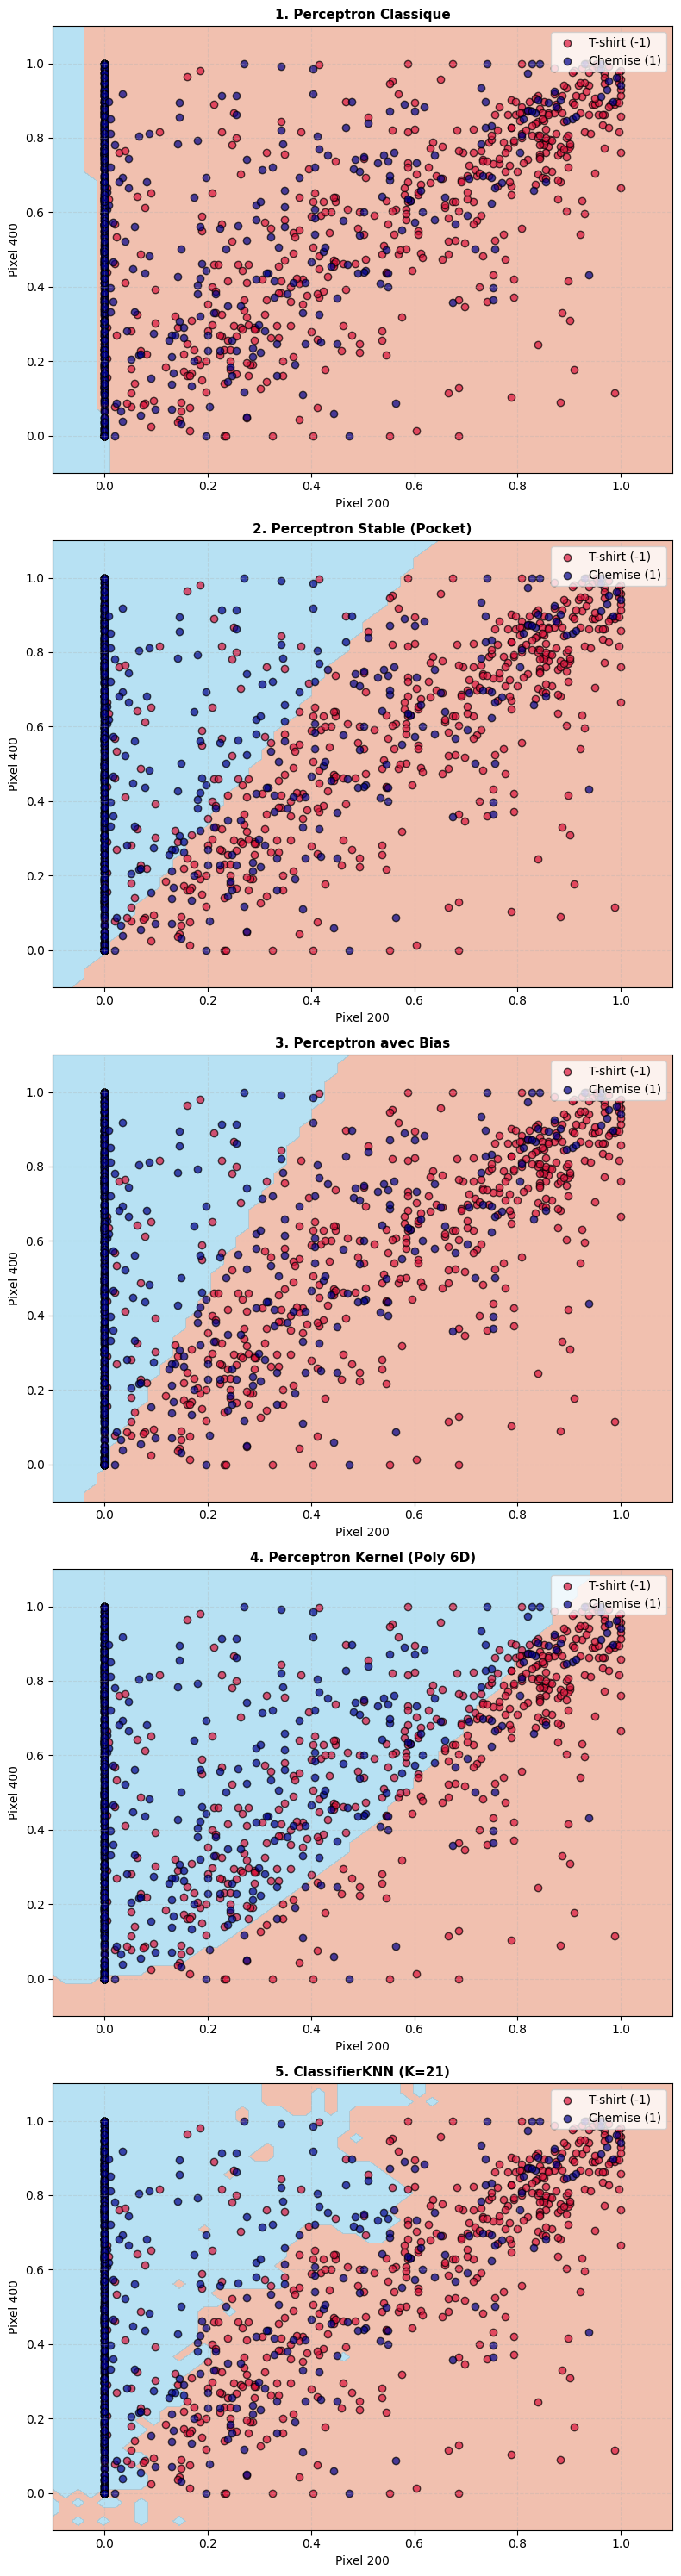

In [18]:
"""
CONCLUSION SUR CLASSIFIERS BINAIRES: visualisation verticale des 5 frontières
"""
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

X_2D = DS_binaire[0][:, [200, 400]]
Y_2D = DS_binaire[1]

X_2D_train = X_2D.astype(np.float64)
Y_2D_train = Y_2D.astype(np.int64)

n_features_2d = 2
learning_rate = 0.01
un_noyau = cl.KernelPoly()

p_classique_2d = cl.ClassifierPerceptron(n_features_2d, learning_rate, init=True)
p_stable_2d = cl.ClassifierPerceptronStable(n_features_2d, learning_rate, init=True)
knn_2d = cl.ClassifierKNN(n_features_2d, k=21)
p_bias = cl.ClassifierPerceptronBias(n_features_2d, learning_rate, init=True)
p_kernel = cl.ClassifierPerceptronKernel(n_features_2d, learning_rate, noyau=un_noyau, init=True)

p_classique_2d.train(X_2D_train, Y_2D_train)
p_stable_2d.train(X_2D_train, Y_2D_train)
knn_2d.train(X_2D_train, Y_2D_train)
p_bias.train(X_2D_train, Y_2D_train)
p_kernel.train(X_2D_train, Y_2D_train)

plt.figure(figsize=(8, 30))

plt.subplot(5, 1, 1)
vis.visualiser_frontiere_2d(X_2D_train, Y_2D_train, p_classique_2d, title="1. Perceptron Classique")
plt.xlabel("Pixel 200")
plt.ylabel("Pixel 400")

plt.subplot(5, 1, 2)
vis.visualiser_frontiere_2d(X_2D_train, Y_2D_train, p_stable_2d, title="2. Perceptron Stable (Pocket)")
plt.xlabel("Pixel 200")
plt.ylabel("Pixel 400")

plt.subplot(5, 1, 3)
vis.visualiser_frontiere_2d(X_2D_train, Y_2D_train, p_bias, title="3. Perceptron avec Bias")
plt.xlabel("Pixel 200")
plt.ylabel("Pixel 400")

plt.subplot(5, 1, 4)
vis.visualiser_frontiere_2d(X_2D_train, Y_2D_train, p_kernel, title="4. Perceptron Kernel (Poly 6D)")
plt.xlabel("Pixel 200")
plt.ylabel("Pixel 400")

plt.subplot(5, 1, 5)
vis.visualiser_frontiere_2d(X_2D_train, Y_2D_train, knn_2d, title="5. ClassifierKNN (K=21)")
plt.xlabel("Pixel 200")
plt.ylabel("Pixel 400")

plt.tight_layout()
plt.show()

### Analyse Visuelle des Frontières de Décision (Projection 2D)

1.Linéarité et contraintes géométriques (Modèles 1, 2 et 3): Les modèles 
Perceptron classique, Stable (Pocket) et avec Biais imposent une 
frontière de décision strictement rectiligne. Sur cette projection 
centrée sur les pixels 200 et 400, on observe que le nuage de 
points est fortement entremêlé. Le Perceptron classique (Graphique 1) 
s'arrête sur une frontière sous-optimale presque verticale isolant 
uniquement la bande dense à gauche. Le Perceptron Stable (Graphique 2) 
et le Perceptron avec Biais (Graphique 3) parviennent à faire pivoter
cette droite selon une diagonale mieux équilibrée, traversant la 
zone de conflit pour maximiser le compromis global.

2.Flexibilité de la frontière non-linéaire polynomiale (Modèle 4) : 
Le Perceptron Kernelisé introduit une distorsion polynomiale d'ordre 6. 
Graphiquement, la frontière n'est plus une ligne droite mais adopte 
un profil incurvé qui tente de contourner les zones de forte densité 
de la classe adverse. Cependant, restreint aux deux seuls pixels 
d'entrée, le modèle ne dispose pas de descripteurs suffisants pour 
scinder proprement le cœur du nuage, ce qui explique pourquoi sa 
frontière reste relativement lisse et n'englobe qu'une portion 
limitée des données.

3.Topologie locale et non-linéarité brute (Modèle 5) : Le ClassifierKNN 
(K=21) se détache radicalement des approches linéaires en générant 
une frontière fragmentée et hautement non-linéaire. Ne dépendant 
pas d'un hyperplan mais de la densité locale des voisins, il dessine 
des îlots et des zones imbriquées adaptées à la dispersion réelle 
des points. Cette cartographie confirme graphiquement sa supériorité 
statistique observée lors de la validation croisée, car il est le seul 
modèle capable d'épouser la complexité géométrique de cet espace 
d'observation restreint.

Conclusion : Cette confrontation visuelle 
illustre les limites des séparateurs linéaires stricts face à des 
classes complexes et imbriquées. Tandis que les variantes Pocket et 
Biais optimisent le placement d'une frontière droite, la méthode des 
plus proches voisins (KNN) démontre sa supériorité naturelle pour 
capturer la topologie locale d'un espace de faible dimension.

In [30]:
# TROISIEME ETAPE: Classifier multiclasse - évaluation via accuracy globale
np.random.seed(42)

X_train_hom, Y_train_hom = ut.echantillonnage_homogene(X_train_raw, Y_train_raw, 0.4)
X_test_hom, Y_test_hom = ut.echantillonnage_homogene(X_test_raw, Y_test_raw, 0.4)

v_dimension = X_train_hom.shape[1]

base_perceptron = cl.ClassifierPerceptronBias(v_dimension, learning_rate=0.01, init=True)
multi_clf = cl.ClassifierMultiOAA(v_dimension, base_perceptron)
multi_clf.train(X_train_hom, Y_train_hom)

final_train_acc = multi_clf.accuracy(X_train_hom, Y_train_hom)
final_test_acc = multi_clf.accuracy(X_test_hom, Y_test_hom)

print(f"Accuracy finale (train) : {final_train_acc * 100:.2f}%")
print(f"Accuracy finale (test)  : {final_test_acc * 100:.2f}%")


Accuracy finale (train) : 61.44%
Accuracy finale (test)  : 49.38%


### Conclusion Intermédiaire : Analyse de l'Accuracy Globale OAA

L'analyse des scores d'accuracy globale obtenus via la stratégie **One-Against-All (OAA)** combinée au `ClassifierPerceptronBias` (avec un paramètre d'échantillonnage de 0.4) met en évidence plusieurs comportements théoriques notables :

1. **Stabilisation du Surapprentissage (Overfitting) :**
   En augmentant la taille de l'échantillon homogène (passage de 0.1 à 0.4), l'accuracy sur le jeu d'entraînement passe de 77.92% à **61.44%**, tandis que l'accuracy de test se stabilise à **49.38%**. La réduction drastique de l'écart entre les deux scores (de 30% à environ 12%) démontre que le modèle ne souffre plus d'une simple mémorisation du bruit, mais se confronte désormais à sa limite de capacité intrinsèque.

2. **Supériorité par rapport au hasard (Baseline) :**
   Bien qu'un score de ~49.4% sur le jeu de test puisse sembler faible dans l'absolu, il convient de rappeler que la tâche comporte **10 classes équilibrées**. Le niveau de prédiction aléatoire pure est donc de 10%. Le classifieur linéaire OAA est ainsi **près de 5 fois plus performant que le hasard**, ce qui valide la justesse algorithmique de son implémentation.

3. **La barrière de la linéarité :**
   Ce plafond de ~50% de généralisation est le symptôme direct de la **non-séparabilité linéaire** globale du dataset Fashion MNIST. Les frontières géométriques qui séparent les 10 catégories de vêtements (aux silhouettes et densités de pixels extrêmement proches) sont hautement non-linéaires. Forcer une approche par hyperplans rigides limite mathématiquement la capture des nuances morphologiques.

*Transition :* Ce score global figé à 49.38% nécessite une investigation plus fine. Les étapes suivantes (Matrice de Confusion et Validation Croisée) permettront de cartographier précisément les intersections de classes problématiques et de valider statistiquement la robustesse de ce plafond.

5. MATRICE DE CONFUSION : MULTICLASSE
[0 1 2 3 4 5 6 7 8 9]


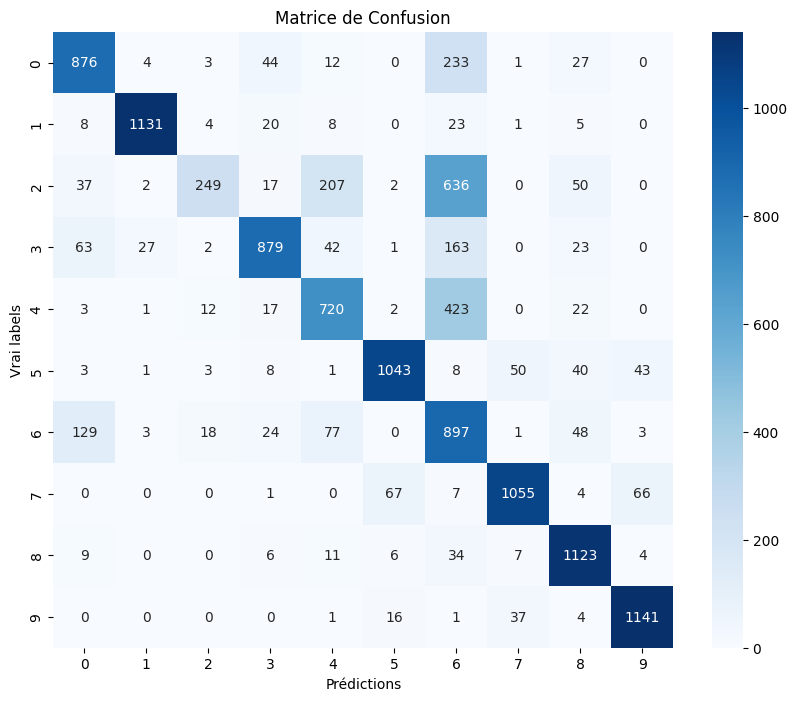

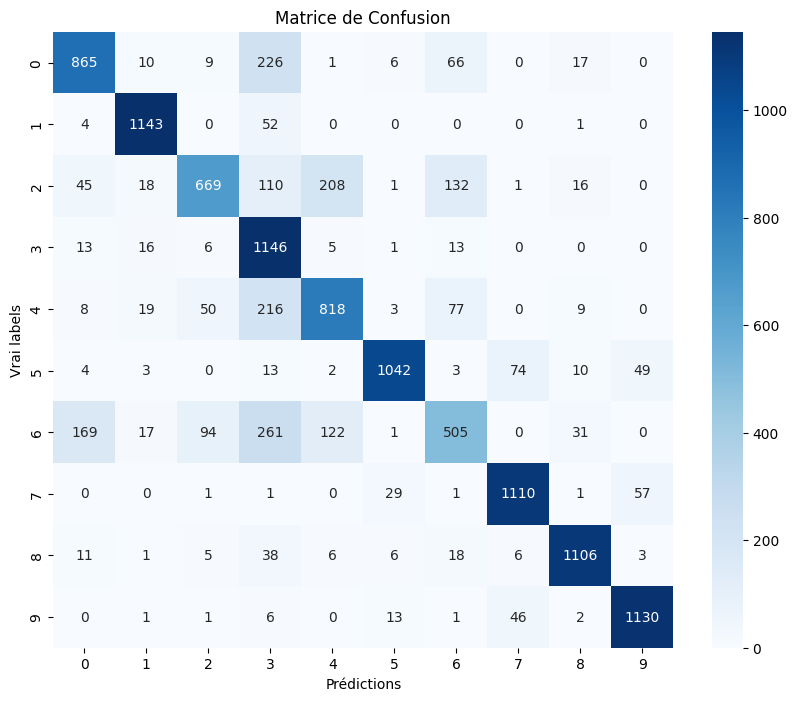

In [ ]:
# TROISIEME ETAPE: Classifier multiclasse - évaluation via matrice de confusion
np.random.seed(42)

Y_train_raw = data_train['label'].to_numpy()
Y_test_raw = data_test['label'].to_numpy()

X_train_raw = data_train.drop(columns=['label']).to_numpy() / 255.0
X_test_raw = data_test.drop(columns=['label']).to_numpy() / 255.0

X_train_hom, Y_train_hom = ut.echantillonnage_homogene(X_train_raw, Y_train_raw, 0.4)

DS_eval = (X_train_hom, Y_train_hom)
v_dimension = X_train_hom.shape[1]

base_perceptron = cl.ClassifierPerceptronBias(v_dimension, learning_rate=0.01, init=True)
multi_clf = cl.ClassifierMultiOAA(v_dimension, base_perceptron)

print("="*60)
print("5. MATRICE DE CONFUSION : MULTICLASSE")
print("="*60)

ev.matrice_de_confusion(multi_clf, DS_eval, nb_iter=2, stratified=True)

### Analyse Résumée de la Matrice de Confusion (Multiclasse OAA)

L'analyse de la matrice de confusion $10 \times 10$ par validation croisée permet de tirer deux conclusions majeures sur le comportement du `ClassifierMultiOAA` :

1. **Succès sur les formes uniques (Trouser, Bag) :** Les classes **1 (Trouser)** et **8 (Bag)** obtiennent les scores les plus élevés (diagonale très dense). Leur silhouette géométrique et la répartition de leurs pixels sont uniques, ce qui permet aux hyperplans linéaires de les isoler facilement des autres catégories.

2. **Confusion critique sur le bloc "Haut du corps" (Shirt, T-shirt, Pullover, Coat) :** On observe une forte dispersion des erreurs (zones bleutées hors-diagonale) entre les classes **0, 2, 4 et 6**. À basse résolution ($28 \times 28$ pixels), ces vêtements partagent une structure spatiale presque identique. Une simple combinaison linéaire de pixels ne peut pas capturer des détails abstraits complexes comme la présence d'un col, de boutons ou l'épaisseur du tissu.

**Conclusion :** L'approche linéaire montre ici ses limites théoriques face à la non-séparabilité globale de Fashion MNIST. Pour dépasser ce plafond de ~50% de généralisation, il est nécessaire de passer à des modèles non-linéaires basés sur des découpages locaux de l'espace, à savoir les **Arbres de Décision**.

5. VALIDATION CROISÉE MULTICLASSE (GRAPHIQUE COMPARAISON)


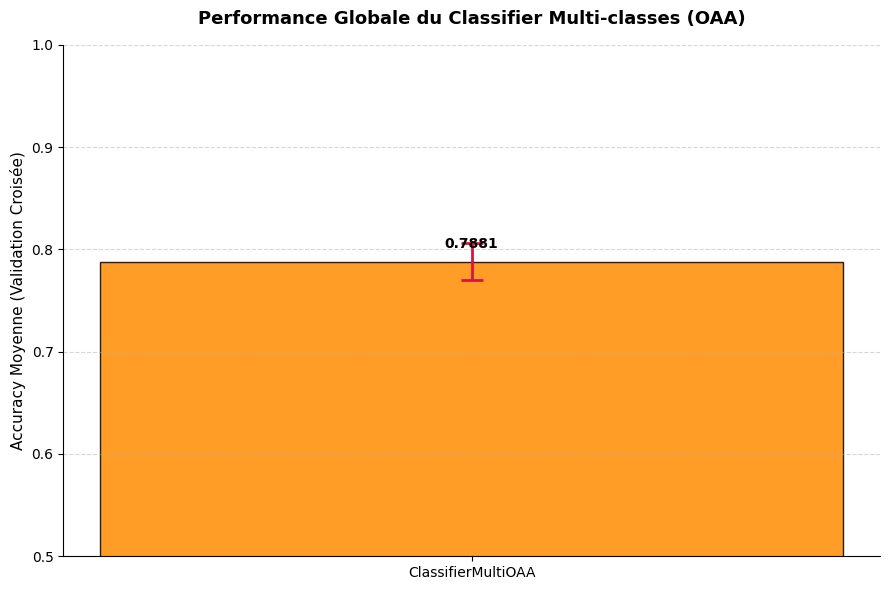

Accuracy Moyenne : 78.81%
Écart-type       : 1.7802


In [38]:
# TROISIEME ETAPE: Classifier multiclasse - évaluation via validation croisée (Graphique)
np.random.seed(42)

X_train_hom, Y_train_hom = ut.echantillonnage_homogene(X_train_raw, Y_train_raw, 0.4)
DS_eval = (X_train_hom, Y_train_hom)
v_dimension = X_train_hom.shape[1]

base_perceptron = cl.ClassifierPerceptronBias(v_dimension, learning_rate=0.01, init=True)
multi_clf = cl.ClassifierMultiOAA(v_dimension, base_perceptron)

print("="*60)
print("5. VALIDATION CROISÉE MULTICLASSE (GRAPHIQUE COMPARAISON)")
print("="*60)

_, moy_multi, std_multi = ev.validation_croisee(multi_clf, DS_eval, nb_iter=4, stratified=True)

noms_multi = ['ClassifierMultiOAA']
moyennes_multi = [moy_multi]
ecarts_types_multi = [std_multi]

vis.plot_comparaison_classifiers(noms_multi, moyennes_multi, ecarts_types_multi, 
                                 title="Performance Globale du Classifier Multi-classes (OAA)")

print(f"Accuracy Moyenne : {moy_multi * 100:.2f}%")
print(f"Écart-type       : {std_multi * 100:.4f}")

### IV. Les Arbres de Décision : Une Approche Non-Linéaire

Pour pallier les limites géométriques des modèles linéaires, qui se sont avérés insuffisants pour capturer la complexité globale de Fashion MNIST, nous introduisons la paradigme des **Arbres de Décision**. Ce modèle non-paramétrique repose sur une stratégie de partitionnement récurrent de l'espace des descripteurs, en effectuant des coupures successives et orthogonales aux axes de coordonnées. Contrairement au Perceptron qui ajuste des poids globaux, l'arbre de décision isole localement des régions de pixels de plus en plus homogènes en optimisant à chaque étape un critère statistique d'hétérogénéité, formalisé par l'**Entropie de Shannon** et le **Gain d'Information**.

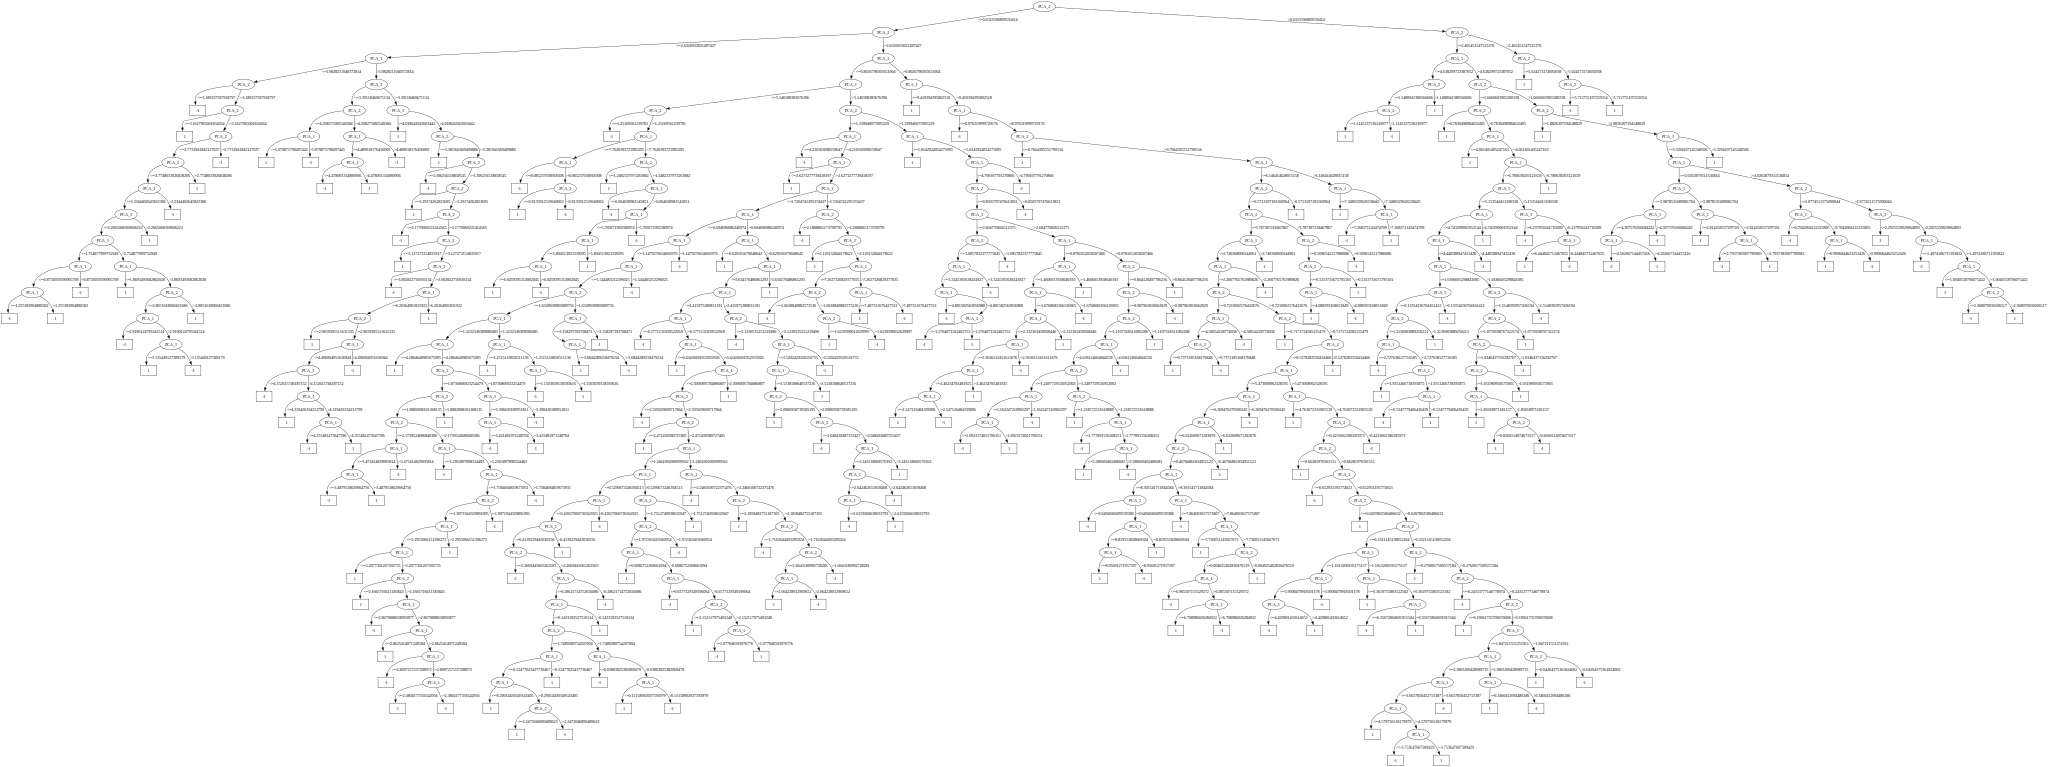

In [45]:
np.random.seed(42)

X_b = DS_binaire[0]
Y_b = DS_binaire[1]

pca_tree = PCA(n_components=2)
X_b_pca = pca_tree.fit_transform(X_b)

arbre_visu = ar.ClassifierArbreNumerique(input_dimension=2, epsilon=0.1, LNoms=['PCA_1', 'PCA_2'])
arbre_visu.train(X_b_pca, Y_b)

g_tree = gv.Digraph('Arbre_Decision', format='png')
arbre_visu.affiche(g_tree)

g_tree.render('arbre_structure', view=False)
g_tree

### Analyse Visuelle de l'Arbre de Décision Numérique

La visualisation du graphe généré par `ClassifierArbreNumerique` permet de mettre en évidence plusieurs propriétés fondamentales de ce modèle :

1. **Complexité structurelle (Profondeur élevée) :** Bien qu'il soit entraîné dans un espace réduit (PCA 2D), l'arbre se développe de manière très dense avec une multitude de niveaux de décision. Cela démontre sa capacité intrinsèque à sur-diviser l'espace pour isoler le moindre bruit ou point atypique.
2. **Coupures orthogonales successives :** Chaque nœud ovale représente un test binaire strict sur l'une des composantes (ex: $x_1 \le seuil$). Les feuilles rectangulaires terminales affichent la classe majoritaire prédite.

**Observation critique :** Cette ramification extrême est le symptôme visuel parfait d'une forte tendance au **sur-apprentissage (overfitting)**. L'arbre ne généralise pas la forme globale, il mémorise géométriquement la position de chaque exemple d'entraînement.

In [47]:
np.random.seed(42)
X_train_tree, Y_train_tree = ut.echantillonnage_homogene(X_train_raw, Y_train_raw, 0.01) 
X_test_tree, Y_test_tree = ut.echantillonnage_homogene(X_test_raw, Y_test_raw, 0.01)

v_dimension = X_train_tree.shape[1]

arbre_complet = ar.ClassifierArbreNumerique(input_dimension=v_dimension, epsilon=0.0)

print("Entraînement de l'arbre complet sur les pixels originaux (veuillez patienter)...")
arbre_complet.train(X_train_tree, Y_train_tree)

acc_train = arbre_complet.accuracy(X_train_tree, Y_train_tree)
acc_test = arbre_complet.accuracy(X_test_tree, Y_test_tree)
nb_feuilles = arbre_complet.number_leaves()

print("="*50)
print(f"Nombre total de feuilles : {nb_feuilles}")
print(f"Accuracy sur Train       : {acc_train * 100:.2f}%")
print(f"Accuracy sur Test        : {acc_test * 100:.2f}%")
print("="*50)

Entraînement de l'arbre complet sur les pixels originaux (veuillez patienter)...
Nombre total de feuilles : 76
Accuracy sur Train       : 100.00%
Accuracy sur Test        : 65.00%


### Analyse des Performances de l'Arbre de Décision Unique

Les résultats numériques confirment quantitativement le phénomène de **sur-apprentissage (overfitting)** propre aux arbres de décision non contraints :

1. **Mémorisation parfaite du Train ($100\%$) :** L'arbre s'est développé jusqu'à obtenir des feuilles totalement pures (entropie nulle), ce qui signifie qu'il a créé des règles d'exclusion sur mesure pour chaque pixel du jeu d'entraînement.
2. **Faible généralisation sur le Test ($65\%$) :** La chute brutale de l'accuracy montre que les critères géométriques rigides trouvés par l'arbre (coupures orthogonales sur des pixels isolés) capturent le bruit des images plutôt que des concepts morphologiques globaux.

**Conclusion :** Un arbre de décision unique possède une variance trop élevée pour être performant sur un dataset complexe comme Fashion MNIST. Pour stabiliser les frontières et réduire cette variance sans perdre en pouvoir non-linéaire, il est indispensable d'introduire la méthode d'ensemble : les **Forêts Aléatoires (Random Forests)**.